In [1]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
# Загрузка данных
df = pd.read_csv("combined_patients.csv")

# Преобразование числовых столбцов
numeric_cols = ["Результат", "Нижний референс", "Верхний референс", "age"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

# Подсчет уникальных пациентов
unique_patients = df["patient_id"].nunique()
print(f"\nКоличество уникальных пациентов: {unique_patients}")

# Преобразование статуса в числовой формат (нормальный=1, низкий=0, высокий=2)
df["status_numeric"] = df["status"].astype(int)

# Добавление признаков отклонения от референсных диапазонов
df["below_min_ref"] = np.maximum(0, df["Нижний референс"] - df["Результат"])
df["above_max_ref"] = np.maximum(0, df["Результат"] - df["Верхний референс"])
df["within_range"] = (
    (df["Результат"] >= df["Нижний референс"])
    & (df["Результат"] <= df["Верхний референс"])
).astype(int)

df.head()


Количество уникальных пациентов: 40


,Анализ,Результат,Уровень,Нижний референс,Верхний референс,status,index,patient_id,age,sex,date,status_numeric,below_min_ref,above_max_ref,within_range
0,Аргинин (Arg),0.91,,0.5,24.0,1,66,261,37,М,2024-06-23,1,0.0,0.0,1
1,Валин (Val),1.69,,0.3,7.5,1,67,261,37,М,2024-06-23,1,0.0,0.0,1
2,Гистидин (His),50.93,,8.0,150.0,1,68,261,37,М,2024-06-23,1,0.0,0.0,1
3,Метионин (Met),0.59,,0.4,9.5,1,69,261,37,М,2024-06-23,1,0.0,0.0,1
4,Треонин (Thr),9.03,,1.6,23.5,1,70,261,37,М,2024-06-23,1,0.0,0.0,1


In [3]:
# Функция для создания табличного набора данных для каждого пациента
def create_patient_table(dataframe):
    """
    Создание табличного набора данных с анализами в качестве столбцов для каждого пациента
    """
    # Создание сводных таблиц для каждого типа значений
    result_pivot = dataframe.pivot_table(
        index=["patient_id", "age", "date"],
        columns="Анализ",
        values="Результат",
        aggfunc="first",
    )

    below_min_pivot = dataframe.pivot_table(
        index=["patient_id", "age", "date"],
        columns="Анализ",
        values="below_min_ref",
        aggfunc="first",
    )
    # Добавление префикса к именам столбцов
    below_min_pivot.columns = [f"{col}_below_min" for col in below_min_pivot.columns]

    above_max_pivot = dataframe.pivot_table(
        index=["patient_id", "age", "date"],
        columns="Анализ",
        values="above_max_ref",
        aggfunc="first",
    )
    # Добавление префикса к именам столбцов
    above_max_pivot.columns = [f"{col}_above_max" for col in above_max_pivot.columns]

    status_pivot = dataframe.pivot_table(
        index=["patient_id", "age", "date"],
        columns="Анализ",
        values="status_numeric",
        aggfunc="first",
    )
    # Добавление префикса к именам столбцов
    status_pivot.columns = [f"{col}_status" for col in status_pivot.columns]

    # Объединение всех сводных таблиц
    combined_pivot = pd.concat(
        [result_pivot, below_min_pivot, above_max_pivot, status_pivot], axis=1
    )

    # Сброс индекса, чтобы patient_id, age и date стали обычными столбцами
    pivot_df = combined_pivot.reset_index()

    return pivot_df


# Создание табличного набора данных
patient_table = create_patient_table(df)

patient_table.head()

,patient_id,age,date,1-Метилгистидин (1-MH),2-Гидрокси-2-метилбутандиовая кислота (лимонно-яблочная кислота),2-Гидрокси-3-метилбутановая кислота (2-гидроксиизовалериановая кислота),2-Гидроксимасляная кислота (2-гидроксибутановая кислота),2-Кетоглутаровая кислота (2-оксоглутаровая кислота),2-Кетоизовалериановая кислота,2-Метилглутаровая (2-метилпентандиовая кислота),...,"Яблочная кислота (малат, оксиянтарная кислота, Е296)_status","Янтарная кислота (сукциновая кислота, сукцинат, Е363)_status",мета-Метилгиппуровая кислота_status,орто-Гидроксифенилуксусная кислота_status,орто-Метилгиппуровая кислота_status,пара-Гидроксибензойная кислота (пара-карбоксифенол)_status,пара-Гидроксифенилмолочная кислота_status,пара-Гидроксифенилпировиноградная кислота_status,пара-Метилгиппуровая кислота_status,цис-Аконитовая кислота (пропилентрикарбоновая)_status
0,261,37,2024-06-23,62.53,1.525,0.140,0.217,3.659,0.150,0.095,...,1,1,1,1,1,1,1,1,1,1
1,266,30,2024-10-17,22.35,0.512,0.017,0.880,2.104,0.266,0.090,...,0,1,2,0,1,1,1,1,1,1
2,268,34,2024-10-26,28.09,1.282,0.056,0.112,1.003,0.068,0.028,...,0,1,1,1,1,1,1,1,1,1
3,271,32,2025-02-22,14.13,0.664,0.039,0.731,1.880,0.143,0.030,...,0,1,1,1,1,1,1,1,1,0
4,272,23,2025-02-22,10.20,3.320,0.064,0.803,0.991,0.059,0.027,...,0,0,1,0,1,1,2,1,1,0


In [4]:
filtered_table = patient_table.copy()

# Определение признаков и целевой переменной (используем возраст как целевую переменную для демонстрации)
X = filtered_table.drop(["patient_id", "age", "date"], axis=1)

y = filtered_table["age"]
groups = filtered_table["patient_id"]  # Используем patient_id для группировки

# Разделение данных по patient_id, чтобы избежать утечки данных
# Это гарантирует, что пациенты из обучающей выборки не появятся в тестовой
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
patient_ids_train = filtered_table["patient_id"].iloc[train_idx]
patient_ids_test = filtered_table["patient_id"].iloc[test_idx]

print(
    f"\nОбучающая выборка: {len(X_train)} образцов, {len(np.unique(patient_ids_train))} уникальных пациентов"
)
print(
    f"Тестовая выборка: {len(X_test)} образцов, {len(np.unique(patient_ids_test))} уникальных пациентов"
)


Обучающая выборка: 32 образцов, 32 уникальных пациентов
Тестовая выборка: 8 образцов, 8 уникальных пациентов


In [5]:
# Создание препроцессинг-конвейера с StandardScaler для масштабирования признаков
numeric_features = X.columns.tolist()
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])

preprocessor = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_features)]
)

# Создание модельных конвейеров
models = {
    "Linear Regression": Pipeline(
        steps=[("preprocessor", preprocessor), ("model", LinearRegression())]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("model", RandomForestRegressor(random_state=42)),
        ]
    ),
}


Обучение и оценка моделей...
Linear Regression - MAE: 5.02, R2: -0.90
Random Forest - MAE: 2.60, R2: 0.34


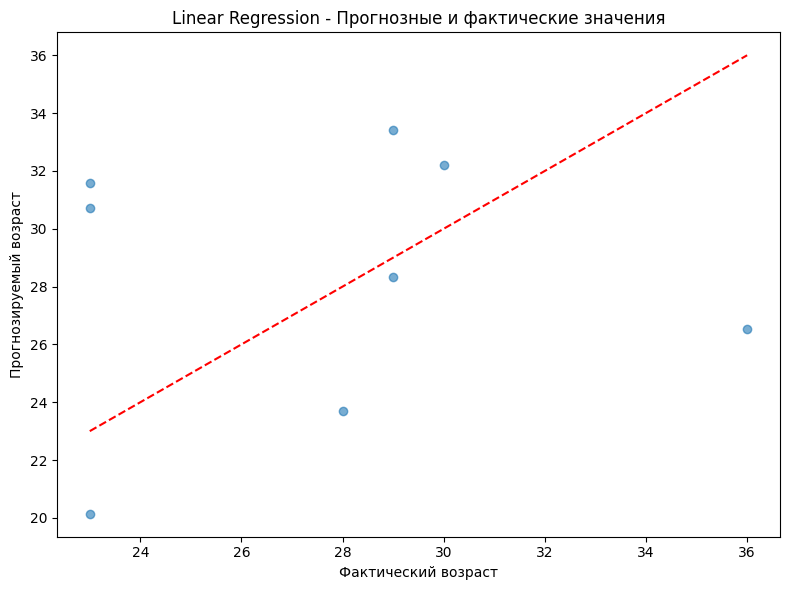

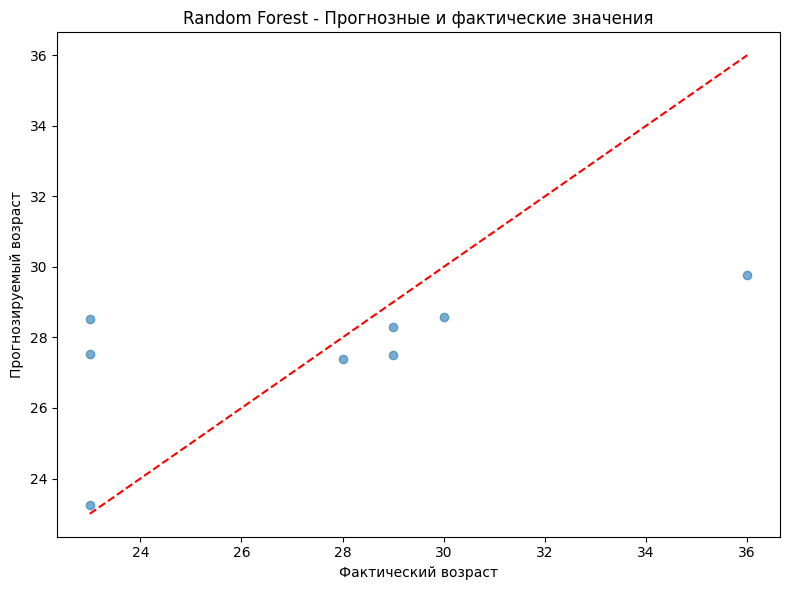

In [6]:
# Обучение и оценка моделей
print("\nОбучение и оценка моделей...")
results = {}
prediction_errors = {}

for name, model in models.items():
    # Обучение модели
    model.fit(X_train, y_train)

    # Прогнозирование
    y_pred = model.predict(X_test)

    # Оценка модели
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    # Расчет абсолютных ошибок для статистического теста
    abs_errors = np.abs(y_test - y_pred)
    prediction_errors[name] = abs_errors

    # Сохранение результатов
    results[name] = {"MAE": mae, "R2": r2, "model": model}

    print(f"{name} - MAE: {mae:.2f}, R2: {r2:.2f}")

    # Визуализация прогнозов и фактических значений
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    plt.title(f"{name} - Прогнозные и фактические значения")
    plt.xlabel("Фактический возраст")
    plt.ylabel("Прогнозируемый возраст")
    plt.tight_layout()

Random Forest против Linear Regression - t-статистика: -4.0478, p-значение: 0.0049
Random Forest значительно лучше, чем Linear Regression


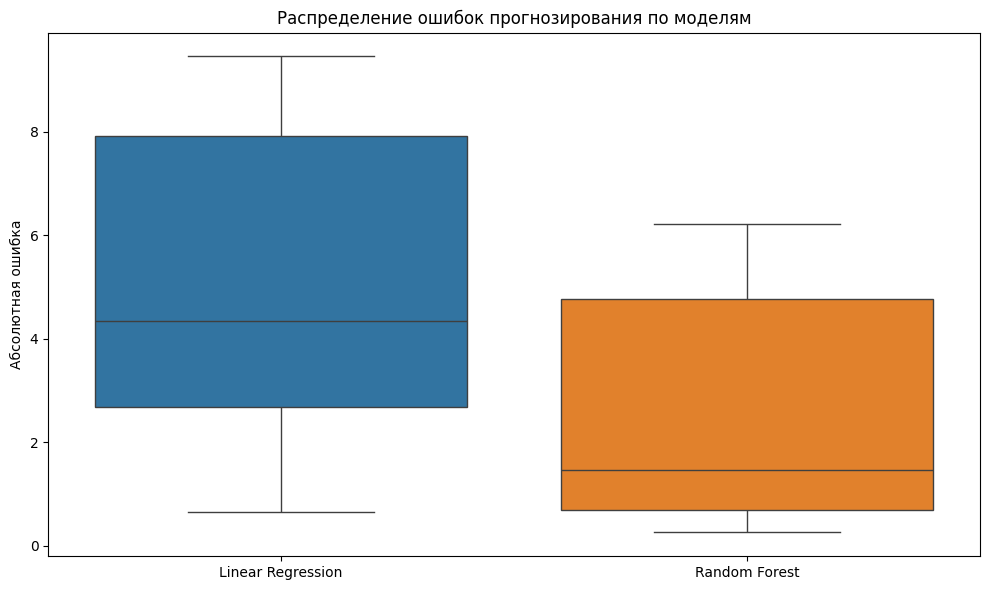

In [7]:
# Парный t-тест для Random Forest и Linear Regression
t_stat_rf_vs_lr, p_value_rf_vs_lr = stats.ttest_rel(
    prediction_errors["Random Forest"], prediction_errors["Linear Regression"]
)
print(
    f"Random Forest против Linear Regression - t-статистика: {t_stat_rf_vs_lr:.4f}, p-значение: {p_value_rf_vs_lr:.4f}"
)
if p_value_rf_vs_lr < 0.05:
    if (
        prediction_errors["Random Forest"].mean()
        < prediction_errors["Linear Regression"].mean()
    ):
        print("Random Forest значительно лучше, чем Linear Regression")
    else:
        print("Linear Regression значительно лучше, чем Random Forest")
else:
    print("Нет значимой разницы между Random Forest и Linear Regression")

# Визуализация распределения ошибок
plt.figure(figsize=(10, 6))
error_data = pd.DataFrame(
    {
        "Linear Regression": prediction_errors["Linear Regression"],
        "Random Forest": prediction_errors["Random Forest"],
    }
)
sns.boxplot(data=error_data)
plt.title("Распределение ошибок прогнозирования по моделям")
plt.ylabel("Абсолютная ошибка")
plt.tight_layout()